<a href="https://colab.research.google.com/github/dibyanshusamal9/Sentinel_Risk_Engine/blob/main/CreditCardFraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import joblib
import warnings
from google.colab import drive

# Suppress minor warnings
warnings.filterwarnings('ignore')

In [ ]:
# --- CELL 2: Load Data, Create Holdout, & Preprocess ---
drive_path = "/content/drive/My Drive/FraudProject/creditcard.csv"

print(f"Loading main dataset from: {drive_path}")
df_full = pd.read_csv(drive_path)

# Preview the first 3 rows of the dataset
print("Dataset Preview:")
display(df_full.head(3))

# CREATE THE HOLDOUT STREAM FOR STREAMLIT
print("Carving out 5,000 rows for the Streamlit live feed...")
# Random state ensures we grab the exact same 5000 rows if you run this again
df_stream = df_full.sample(n=5000, random_state=99)

# Save the raw holdout set to Drive temporarily
holdout_path = "/content/drive/My Drive/FraudProject/raw_holdout_stream.csv"
df_stream.to_csv(holdout_path, index=False)

# PREVENT DATA LEAKAGE: Drop these 5,000 rows from the training data
df = df_full.drop(df_stream.index)
print(f"Training data shape after removing holdout: {df.shape}\n")

# Proceed with Feature Engineering on the remaining data
print("Engineering cyclical time features...")
df['Hour_of_Day'] = (df['Time'] // 3600) % 24

# Scaling
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

# Drop original unscaled columns and rearrange
df = df.drop(['Time', 'Amount'], axis=1)
X = df.drop('Class', axis=1)
y = df['Class']

print("Preprocessing complete. Features ready for splitting.")

Loading main dataset from: /content/drive/My Drive/FraudProject/creditcard.csv
Dataset Preview:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


Carving out 5,000 rows for the Streamlit live feed...
Training data shape after removing holdout: (279807, 31)

Engineering cyclical time features...
Preprocessing complete. Features ready for splitting.


In [ ]:
# Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# Calculate XGBoost's scale_pos_weight to handle the severe imbalance
num_neg = np.sum(y_train == 0)
num_pos = np.sum(y_train == 1)
estimated_weight = num_neg / num_pos

print(f"\nLegitimate transactions in train: {num_neg}")
print(f"Fraudulent transactions in train: {num_pos}")
print(f"Calculated scale_pos_weight: {estimated_weight:.2f}")

Training set shape: (223845, 30)
Testing set shape: (55962, 30)

Legitimate transactions in train: 223460
Fraudulent transactions in train: 385
Calculated scale_pos_weight: 580.42


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, average_precision_score

print("Starting Hyperparameter Tuning (This will take a few minutes)...")

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 200],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=estimated_weight,
    eval_metric="logloss",
    random_state=42
)

# Optimize specifically for PR-AUC
pr_auc_scorer = make_scorer(average_precision_score, needs_proba=True)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=20, # Tests 20 random combinations
    scoring=pr_auc_scorer,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print(f"\nBest Parameters Found: {random_search.best_params_}")

# Overwrite 'model' with the best version found
model = random_search.best_estimator_
print("\nOptimal model trained and ready!")

Starting Hyperparameter Tuning (This will take a few minutes)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Parameters Found: {'subsample': 1.0, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 1.0}

Optimal model trained and ready!


=== Baseline Evaluation (Threshold = 0.5) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55866
           1       0.90      0.85      0.88        96

    accuracy                           1.00     55962
   macro avg       0.95      0.93      0.94     55962
weighted avg       1.00      1.00      1.00     55962

Precision-Recall AUC: 0.8672

--- Calculated Optimal Threshold: 0.4648 ---

=== Evaluation with Optimal Threshold (0.4648) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55866
           1       0.89      0.86      0.88        96

    accuracy                           1.00     55962
   macro avg       0.95      0.93      0.94     55962
weighted avg       1.00      1.00      1.00     55962

Confusion Matrix:


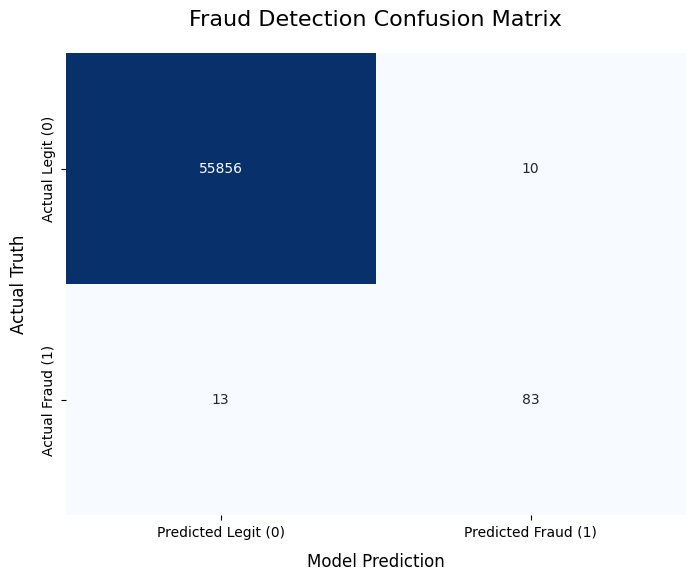

In [ ]:
# --- Evaluation & Threshold Tuning ---
# Get probabilities
y_pred_prob = model.predict_proba(X_test)[:, 1]

# 1. Baseline Evaluation (Threshold 0.5)
y_pred_default = (y_pred_prob >= 0.5).astype(int)
print("=== Baseline Evaluation (Threshold = 0.5) ===")
print(classification_report(y_test, y_pred_default))

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
print(f"Precision-Recall AUC: {auc(recall, precision):.4f}\n")

# 2. Find Optimal Threshold using F2 Score (Prioritizes Recall)
# Adding a tiny epsilon (1e-8) to avoid division by zero
f2_scores = (5 * precision[:-1] * recall[:-1]) / ((4 * precision[:-1]) + recall[:-1] + 1e-8)
optimal_idx = np.argmax(f2_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"--- Calculated Optimal Threshold: {optimal_threshold:.4f} ---")

# 3. Optimized Evaluation
y_pred_optimal = (y_pred_prob >= optimal_threshold).astype(int)

print(f"\n=== Evaluation with Optimal Threshold ({optimal_threshold:.4f}) ===")
print(classification_report(y_test, y_pred_optimal))
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_optimal)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Legit (0)', 'Predicted Fraud (1)'],
            yticklabels=['Actual Legit (0)', 'Actual Fraud (1)'])
plt.title('Fraud Detection Confusion Matrix', fontsize=16, pad=20)
plt.xlabel('Model Prediction', fontsize=12, labelpad=10)
plt.ylabel('Actual Truth', fontsize=12, labelpad=10)
plt.show()

In [ ]:
# --- Export Artifacts & Zip Holdout ---
from google.colab import files
import os
import pandas as pd

# Save ML Artifacts back to your Google Drive folder
save_path = "/content/drive/My Drive/FraudProject/"
print(f"Saving model and scaler to {save_path}...")

joblib.dump(model, os.path.join(save_path, "model.pkl"))
joblib.dump(scaler, os.path.join(save_path, "scaler.pkl"))
print("Model artifacts saved to Drive!")

# Zip the Holdout Stream
print("\nZipping the raw holdout stream for Streamlit...")
holdout_path = "/content/drive/My Drive/FraudProject/raw_holdout_stream.csv"

# Load the raw holdout data
lightweight_test_data = pd.read_csv(holdout_path)

# Zip it
zip_filename = "external_test_dataset.zip"
compression_opts = dict(method='zip', archive_name='external_test_dataset.csv')

lightweight_test_data.to_csv(zip_filename, index=False, compression=compression_opts)
print(f"Test stream zipped successfully into {zip_filename}")

# 3. Download files to local machine for deployment
print("\nDownloading files to your local machine...")
files.download("external_test_dataset.zip")
files.download(os.path.join(save_path, "model.pkl"))
files.download(os.path.join(save_path, "scaler.pkl"))

Saving model and scaler to /content/drive/My Drive/FraudProject/...
Model artifacts saved to Drive!

Zipping the raw holdout stream for Streamlit...
Test stream zipped successfully into external_test_dataset.zip



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>